In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Book1.csv')

In [3]:
df.head()

,Time,Transaction_Amount_Ratio,Transaction_Frequency,Merchant_Risk_Score,Customer_Risk_Score,Account_Age_Months,Device_Trust_Score,Location_Risk_Score,Transaction_Velocity,Cardholder_Behavior_Score,Fraud_Risk_Index,Amount,Class
0,138242,-4.280,4.466,3.507,-3.933,-3.126,-1.142,0.894,-3.402,1.188,-4.603,897.38,0
1,133725,-3.542,2.623,-0.102,3.883,-4.359,3.300,4.044,3.215,3.555,-2.445,1871.49,0
2,43798,-2.914,4.797,-1.450,0.252,1.718,4.812,0.175,3.639,-4.459,2.002,1281.38,0
3,122976,-2.646,-0.636,0.917,-2.126,1.309,-4.204,-2.319,-2.519,-3.083,4.216,2322.21,0
4,152224,-0.541,1.73,-2.082,1.822,1.519,-4.392,-4.246,3.285,2.744,4.563,3737.36,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time                       2000 non-null   int64  
 1   Transaction_Amount_Ratio   1932 non-null   float64
 2   Transaction_Frequency      2000 non-null   object 
 3   Merchant_Risk_Score        2000 non-null   float64
 4   Customer_Risk_Score        2000 non-null   float64
 5   Account_Age_Months         2000 non-null   float64
 6   Device_Trust_Score         2000 non-null   float64
 7   Location_Risk_Score        2000 non-null   float64
 8   Transaction_Velocity       2000 non-null   float64
 9   Cardholder_Behavior_Score  2000 non-null   float64
 10  Fraud_Risk_Index           2000 non-null   float64
 11  Amount                     2000 non-null   object 
 12  Class                      2000 non-null   int64  
dtypes: float64(9), int64(2), object(2)
memory usage:

In [5]:
df.describe()

,Time,Transaction_Amount_Ratio,Merchant_Risk_Score,Customer_Risk_Score,Account_Age_Months,Device_Trust_Score,Location_Risk_Score,Transaction_Velocity,Cardholder_Behavior_Score,Fraud_Risk_Index,Class
count,2000.000000,1932.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,86712.530500,-0.044351,0.124284,0.024279,-0.067985,-0.018830,-0.061303,-0.055052,-0.057182,0.057139,0.025000
std,50180.867428,2.906081,2.891068,2.871806,2.918935,2.912682,2.823994,2.866388,2.817672,2.912554,0.156164
min,1.000000,-4.999000,-5.000000,-4.998000,-4.999000,-4.999000,-4.995000,-4.985000,-4.984000,-4.993000,0.000000
25%,43824.250000,-2.584750,-2.394250,-2.334500,-2.608250,-2.607000,-2.478250,-2.620250,-2.509000,-2.405250,0.000000
50%,89486.500000,-0.048000,0.138000,0.023500,-0.101500,-0.040500,-0.040500,-0.010500,-0.119500,0.028000,0.000000
75%,129596.750000,2.447250,2.634250,2.516750,2.417250,2.561750,2.312750,2.390000,2.300750,2.674500,0.000000
max,172787.000000,4.996000,4.995000,4.999000,4.998000,4.992000,4.991000,4.996000,4.985000,4.997000,1.000000


In [6]:
df.isnull().sum()

Time                          0
Transaction_Amount_Ratio     68
Transaction_Frequency         0
Merchant_Risk_Score           0
Customer_Risk_Score           0
Account_Age_Months            0
Device_Trust_Score            0
Location_Risk_Score           0
Transaction_Velocity          0
Cardholder_Behavior_Score     0
Fraud_Risk_Index              0
Amount                        0
Class                         0
dtype: int64

In [7]:
df['Transaction_Amount_Ratio'].fillna(df['Transaction_Amount_Ratio'].mean(), inplace = True)

In [8]:
df.isnull().sum()

Time                         0
Transaction_Amount_Ratio     0
Transaction_Frequency        0
Merchant_Risk_Score          0
Customer_Risk_Score          0
Account_Age_Months           0
Device_Trust_Score           0
Location_Risk_Score          0
Transaction_Velocity         0
Cardholder_Behavior_Score    0
Fraud_Risk_Index             0
Amount                       0
Class                        0
dtype: int64

In [9]:
df.shape

(2000, 13)

In [11]:
df.drop_duplicates(inplace = True)

In [12]:
df.shape

(2000, 13)

In [13]:
df.replace(['?', 'error'], np.nan, inplace = True)

In [15]:
df.isnull().sum()

Time                          0
Transaction_Amount_Ratio      0
Transaction_Frequency        20
Merchant_Risk_Score           0
Customer_Risk_Score           0
Account_Age_Months            0
Device_Trust_Score            0
Location_Risk_Score           0
Transaction_Velocity          0
Cardholder_Behavior_Score     0
Fraud_Risk_Index              0
Amount                       39
Class                         0
dtype: int64

In [21]:
for col in df.columns:
    if col != 'class':                                         #coverting the columns into numerical data type
        df[col] = pd.to_numeric(df[col], errors = 'coerce')    #errors = 'coerce' tells pandas what to do if non-numeric values encountered

In [23]:
df.fillna(df.median(numeric_only = True), inplace = True)

In [24]:
df.isnull().sum()

Time                         0
Transaction_Amount_Ratio     0
Transaction_Frequency        0
Merchant_Risk_Score          0
Customer_Risk_Score          0
Account_Age_Months           0
Device_Trust_Score           0
Location_Risk_Score          0
Transaction_Velocity         0
Cardholder_Behavior_Score    0
Fraud_Risk_Index             0
Amount                       0
Class                        0
dtype: int64

#EDA

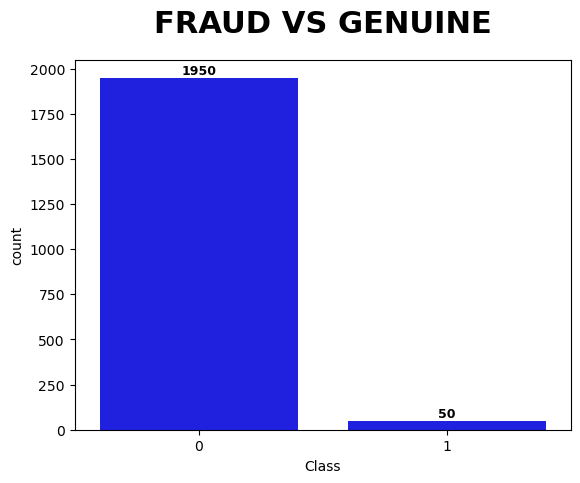

In [46]:
ax = sns.countplot(x='Class', data=df, color = 'blue')

for container in ax.containers:
    ax.bar_label(container,fontsize = 9,fontweight='bold')
plt.title("FRAUD VS GENUINE",fontsize = 22, color = 'black', fontweight='bold', pad = 20 )
plt.show()

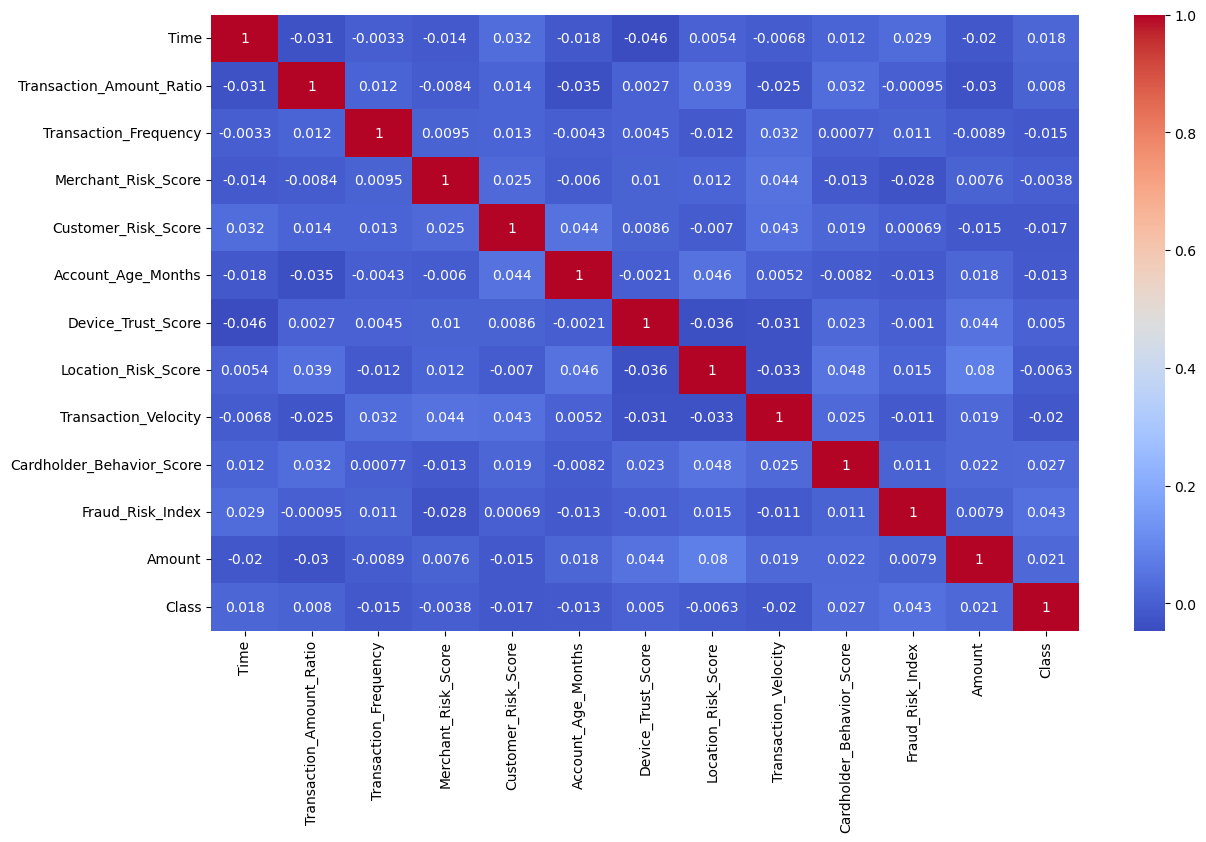

In [51]:
plt.figure(figsize = (14,8))
sns.heatmap(df.corr(), cmap = "coolwarm", annot = True)
plt.show()

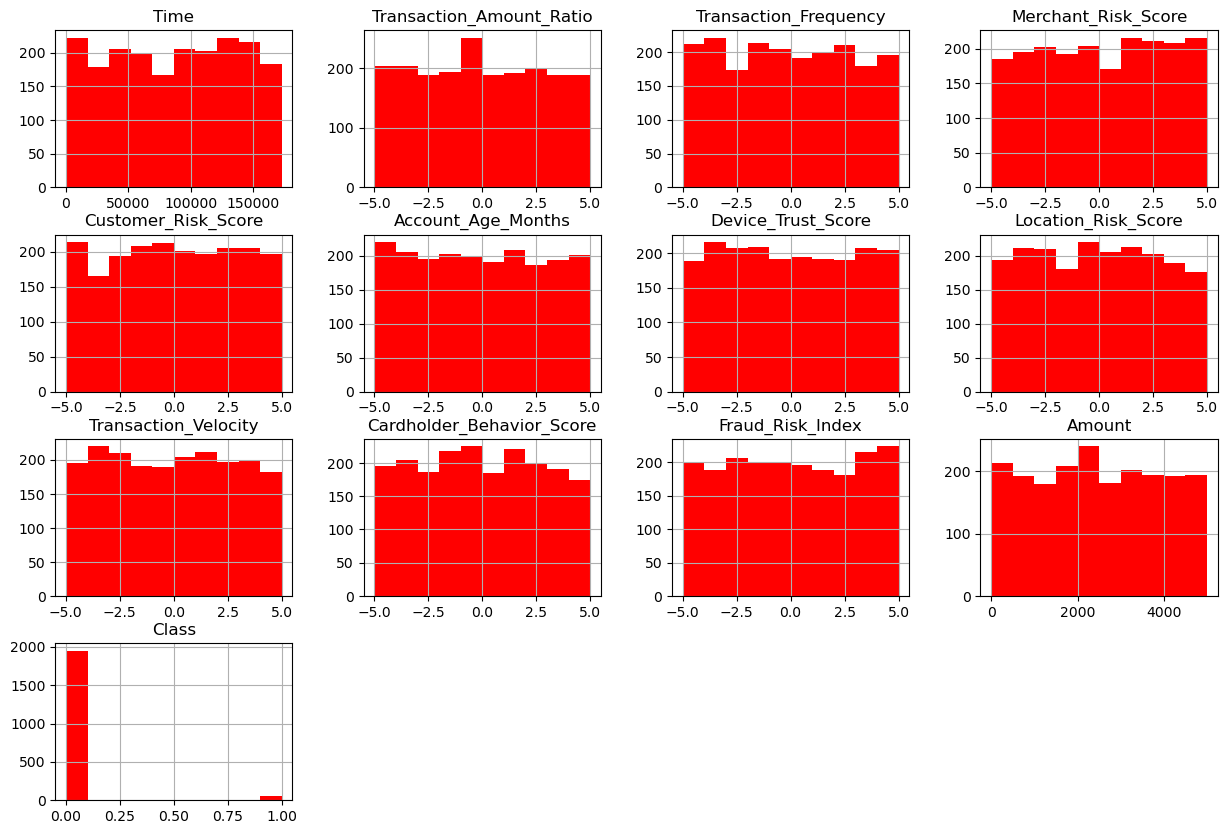

In [58]:
df.hist(figsize=(15,10), color = 'red')
plt.show()

In [ ]:
"""Time : Spread fairly evenly across the dataset. There is no obvious concentration at a particular time.
Transaction_Amount_Ratio: Balanced distribution.
Transaction_Frequency: Different frequencies with no dominant frequency range.
Merchant_Risk_Score: Spread across the dataset without strong skewness.
Customer_Risk_Score: Customer risk scores are reasonably balanced and do not show extreme concentrations.
Account_Age_Months: Indicating a variety of customer account ages.
Device_Trust_Score: No obvious bias toward low or high values.
Location_Risk_Score: Values are spread throughout the range, suggesting diverse transaction locations.
Transaction_Velocity: Fairly evenly distributed and does not show significant skewness.
Cardholder_Behavior_Score: Well distributed with no major outliers visible.
Fraud_Risk_Index: Appear approximately balanced.
Amount: With no severe skewness or clustering."""

<function matplotlib.pyplot.show(close=None, block=None)>

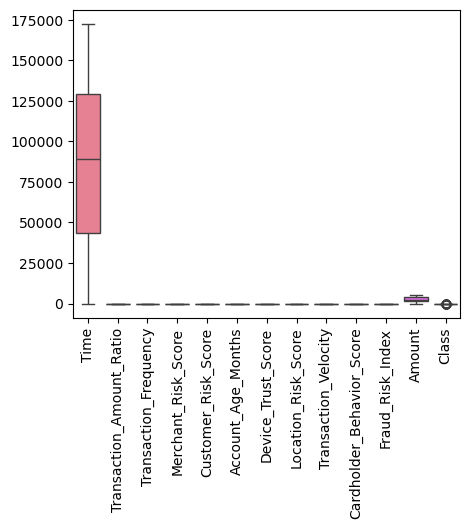

In [118]:
plt.figure(figsize = (5,4))
sns.boxplot(data = df)
plt.xticks(rotation=90)
plt.show

#Feature Selection

In [63]:
x = df.drop('Class', axis = 1)
y = df['Class']

#Feature scaling

In [68]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()
X = scaler.fit_transform(x)

In [69]:
X

array([[ 1.02713164, -1.48332418,  1.57409402, ...,  0.44202906,
        -1.60041837, -1.1007948 ],
       [ 0.93709474, -1.2248766 ,  0.93642973, ...,  1.28229434,
        -0.85930253, -0.4218524 ],
       [-0.85541094, -1.00495102,  1.68861756, ..., -1.56260889,
         0.66791812, -0.83315164],
       ...,
       [-1.56573968,  1.131619  ,  1.39694583, ...,  0.43563921,
         0.38356042,  1.14308644],
       [-0.79674843,  0.14895788, -1.66439635, ...,  1.01782554,
        -0.29951623,  0.52258644],
       [-1.66751706,  0.99539121,  0.39045347, ..., -1.35635873,
        -0.05327895,  0.09531225]], shape=(2000, 12))

In [70]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.20,random_state=42)

In [71]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [72]:
y_pred = model.predict(x_test)

In [73]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [74]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [75]:
accuracy_score(y_test,y_pred)

0.97

In [76]:
confusion_matrix(y_test,y_pred)

array([[388,   0],
       [ 12,   0]])

In [77]:
 print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       388
           1       0.00      0.00      0.00        12

    accuracy                           0.97       400
   macro avg       0.48      0.50      0.49       400
weighted avg       0.94      0.97      0.96       400



In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [79]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [80]:
from sklearn.neighbors import KNeighborsClassifier

In [81]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(x_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [82]:
y_pred_knn = knn_model.predict(x_test_scaled)

In [83]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [84]:
 accuracy_score(y_test,y_pred_knn)

0.97

In [85]:
confusion_matrix(y_test,y_pred)

array([[388,   0],
       [ 12,   0]])

In [95]:
 print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       388
           1       0.00      0.00      0.00        12

    accuracy                           0.97       400
   macro avg       0.48      0.50      0.49       400
weighted avg       0.94      0.97      0.96       400



In [96]:
from sklearn.tree import DecisionTreeClassifier

In [97]:
model_dt = DecisionTreeClassifier(random_state = 42)

In [98]:
model_dt.fit(x_train_scaled,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [99]:
y_pred_dt = model_dt.predict(x_test_scaled)

In [100]:
accuracy_score(y_test,y_pred_dt)

0.935

In [101]:
confusion_matrix(y_test,y_pred_dt)

array([[374,  14],
       [ 12,   0]])

In [102]:
 print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       388
           1       0.00      0.00      0.00        12

    accuracy                           0.97       400
   macro avg       0.48      0.50      0.49       400
weighted avg       0.94      0.97      0.96       400



In [103]:
from xgboost import XGBRegressor

In [104]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [105]:
xgb_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [106]:
red_xgb = xgb_model.predict(x_test)

In [107]:
accuracy_score(y_test,y_pred_dt)

0.935

In [108]:
confusion_matrix(y_test,y_pred_dt)

array([[374,  14],
       [ 12,   0]])

In [109]:
 print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       388
           1       0.00      0.00      0.00        12

    accuracy                           0.97       400
   macro avg       0.48      0.50      0.49       400
weighted avg       0.94      0.97      0.96       400



In [111]:
from sklearn.ensemble import RandomForestClassifier

In [113]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

In [114]:
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
accuracy_score(y_test,y_pred_dt)

0.935

In [116]:
confusion_matrix(y_test,y_pred_dt)

array([[374,  14],
       [ 12,   0]])

In [117]:
 print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       388
           1       0.00      0.00      0.00        12

    accuracy                           0.97       400
   macro avg       0.48      0.50      0.49       400
weighted avg       0.94      0.97      0.96       400

